## APPS Dataset: What does it look like?

Here I vibe-coded some quick analysis of APPS, looking at:
- How many problems have human solutions, what the distribution of # of solutions looks like, and how this varies across the train/test split.
- Similarly looking at the distribution of easy/medium/hard problems across problem_id's.

Ultimately we'd like to carve out train/test/validation splits for our self-rec/control experiments, and this requires knowing how the above vary with problem_id. More details in this doc:
https://docs.google.com/document/d/1ozN8S7O0oQEL0tE-8-TZV4klW-wSj6NNoebsXPuGuRQ/edit?tab=t.0

**Note: this was entirely written by Cursor, I can't 100% vouch for all the code being right.**

In [2]:
# APPS Dataset EDA: Human Solutions Distribution
# This notebook explores the distribution of human solutions per problem in the APPS dataset

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from datasets import load_dataset
import seaborn as sns

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")


In [3]:
# Load the APPS dataset
print("Loading APPS dataset...")
ds_train = load_dataset("codeparrot/apps", split="train")
ds_test = load_dataset("codeparrot/apps", split="test")
print(f"Dataset loaded successfully!")

# Convert to list for easier processing
train_problems = list(ds_train)
test_problems = list(ds_test)
print(f"Train problems: {len(train_problems)}")
print(f"Test problems: {len(test_problems)}")
print(f"Total problems: {len(train_problems) + len(test_problems)}")
print(f"Features: {list(train_problems[0].keys()) if train_problems else 'No problems loaded'}")


Loading APPS dataset...
Dataset loaded successfully!
Train problems: 5000
Test problems: 5000
Total problems: 10000
Features: ['problem_id', 'question', 'solutions', 'input_output', 'difficulty', 'url', 'starter_code']


### Human solutions:
We find out the distribution of human solutions across problems

In [4]:
# Analyze the distribution of human solutions per problem
print("Analyzing human solutions distribution...")

def analyze_solutions(problems, split_name):
    solutions_counts = []
    empty_solutions_count = 0
    
    for i, problem in enumerate(problems):
        solutions_str = problem["solutions"]
        
        # Handle empty or malformed solutions
        if not solutions_str or solutions_str.strip() == "":
            solutions_counts.append(0)
            empty_solutions_count += 1
            continue
            
        try:
            # Parse the solutions JSON string
            solutions = json.loads(solutions_str)
            solutions_counts.append(len(solutions))
        except json.JSONDecodeError as e:
            # Handle malformed JSON
            print(f"Warning: JSON decode error for problem {i} in {split_name} split: {e}")
            solutions_counts.append(0)
            empty_solutions_count += 1
    
    print(f"\n{split_name.upper()} SPLIT:")
    print(f"Total problems analyzed: {len(solutions_counts)}")
    print(f"Problems with empty/malformed solutions: {empty_solutions_count}")
    print(f"Total human solutions: {sum(solutions_counts)}")
    print(f"Average solutions per problem: {np.mean(solutions_counts):.2f}")
    print(f"Median solutions per problem: {np.median(solutions_counts):.2f}")
    print(f"Min solutions per problem: {min(solutions_counts)}")
    print(f"Max solutions per problem: {max(solutions_counts)}")
    
    return solutions_counts

train_solutions_counts = analyze_solutions(train_problems, "train")
test_solutions_counts = analyze_solutions(test_problems, "test")

# Combined stats
all_solutions_counts = train_solutions_counts + test_solutions_counts
print(f"\nCOMBINED:")
print(f"Total problems analyzed: {len(all_solutions_counts)}")
print(f"Total human solutions: {sum(all_solutions_counts)}")
print(f"Average solutions per problem: {np.mean(all_solutions_counts):.2f}")
print(f"Median solutions per problem: {np.median(all_solutions_counts):.2f}")
print(f"Min solutions per problem: {min(all_solutions_counts)}")
print(f"Max solutions per problem: {max(all_solutions_counts)}")


Analyzing human solutions distribution...

TRAIN SPLIT:
Total problems analyzed: 5000
Problems with empty/malformed solutions: 0
Total human solutions: 117232
Average solutions per problem: 23.45
Median solutions per problem: 10.00
Min solutions per problem: 1
Max solutions per problem: 990

TEST SPLIT:
Total problems analyzed: 5000
Problems with empty/malformed solutions: 1235
Total human solutions: 115212
Average solutions per problem: 23.04
Median solutions per problem: 19.00
Min solutions per problem: 0
Max solutions per problem: 100

COMBINED:
Total problems analyzed: 10000
Total human solutions: 232444
Average solutions per problem: 23.24
Median solutions per problem: 10.00
Min solutions per problem: 0
Max solutions per problem: 990


Creating bar charts with improved binning...


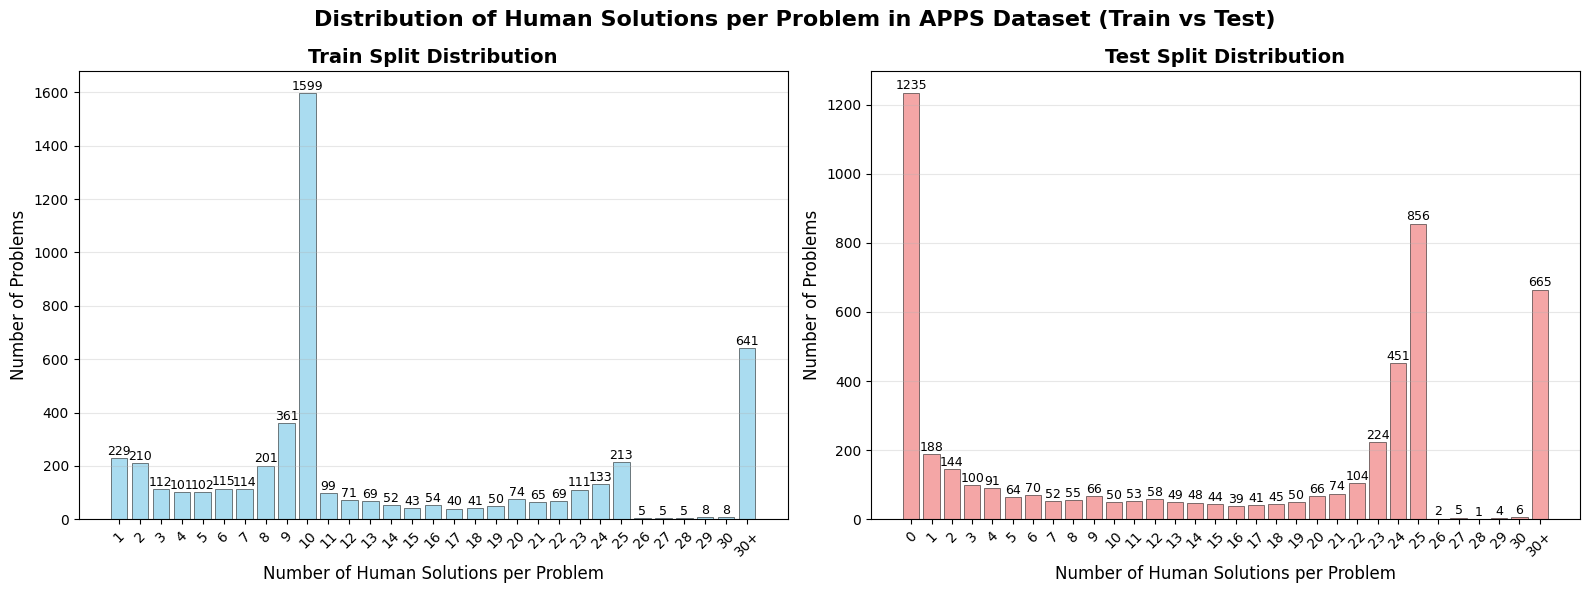


Key Statistics:

TRAIN SPLIT:
Most common number of solutions per problem: 10 solutions (1599 problems)
Problems with exactly 1 solution: 229
Problems with 5+ solutions: 4348
Problems with 10+ solutions: 3455
Problems with 30+ solutions: 641

TEST SPLIT:
Most common number of solutions per problem: 0 solutions (1235 problems)
Problems with exactly 1 solution: 188
Problems with 5+ solutions: 3242
Problems with 10+ solutions: 2935
Problems with 30+ solutions: 665


In [5]:
# Create improved bar charts with better binning
print("Creating bar charts with improved binning...")

# Configuration: Change this value to adjust the threshold for binning
MAX_BIN_THRESHOLD = 30

def create_binned_distribution(solutions_counts, max_bin=MAX_BIN_THRESHOLD):
    """Create a binned distribution with a threshold for high values"""
    # Count how many problems have exactly X solutions (up to max_bin)
    solutions_distribution = Counter(solutions_counts)
    
    # Create binned distribution with proper x-axis labels
    binned_dist = {}
    high_count = 0  # Count of problems with more than max_bin solutions
    
    for num_sols, count in solutions_distribution.items():
        if num_sols <= max_bin:
            binned_dist[num_sols] = count
        else:
            high_count += count
    
    # Add the "{max_bin}+" bin if there are any high values
    if high_count > 0:
        binned_dist[max_bin + 1] = high_count  # Use max_bin + 1 as the key for plotting
    
    return binned_dist, high_count

# Create distributions for both splits
train_dist, train_high_count = create_binned_distribution(train_solutions_counts)
test_dist, test_high_count = create_binned_distribution(test_solutions_counts)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Train split plot
train_x = list(train_dist.keys())
train_y = list(train_dist.values())
bars1 = ax1.bar(train_x, train_y, alpha=0.7, edgecolor='black', linewidth=0.5, color='skyblue')

ax1.set_xlabel('Number of Human Solutions per Problem', fontsize=12)
ax1.set_ylabel('Number of Problems', fontsize=12)
ax1.set_title('Train Split Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Create proper x-axis labels
train_labels = [str(x) if x <= MAX_BIN_THRESHOLD else f'{MAX_BIN_THRESHOLD}+' for x in train_x]
ax1.set_xticks(train_x)
ax1.set_xticklabels(train_labels, rotation=45)

# Add value labels on top of bars
for bar, count in zip(bars1, train_y):
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom', fontsize=9)

# Test split plot
test_x = list(test_dist.keys())
test_y = list(test_dist.values())
bars2 = ax2.bar(test_x, test_y, alpha=0.7, edgecolor='black', linewidth=0.5, color='lightcoral')

ax2.set_xlabel('Number of Human Solutions per Problem', fontsize=12)
ax2.set_ylabel('Number of Problems', fontsize=12)
ax2.set_title('Test Split Distribution', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Create proper x-axis labels
test_labels = [str(x) if x <= MAX_BIN_THRESHOLD else f'{MAX_BIN_THRESHOLD}+' for x in test_x]
ax2.set_xticks(test_x)
ax2.set_xticklabels(test_labels, rotation=45)

# Add value labels on top of bars
for bar, count in zip(bars2, test_y):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution of Human Solutions per Problem in APPS Dataset (Train vs Test)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key statistics for both splits
print(f"\nKey Statistics:")
print(f"\nTRAIN SPLIT:")
most_common_train = max(train_dist.items(), key=lambda x: x[1])
most_common_label = str(most_common_train[0]) if most_common_train[0] <= MAX_BIN_THRESHOLD else f'{MAX_BIN_THRESHOLD}+'
print(f"Most common number of solutions per problem: {most_common_label} solutions ({most_common_train[1]} problems)")
print(f"Problems with exactly 1 solution: {train_dist.get(1, 0)}")
print(f"Problems with 5+ solutions: {sum(count for num_sols, count in train_dist.items() if num_sols >= 5)}")
print(f"Problems with 10+ solutions: {sum(count for num_sols, count in train_dist.items() if num_sols >= 10)}")
print(f"Problems with {MAX_BIN_THRESHOLD}+ solutions: {train_high_count}")

print(f"\nTEST SPLIT:")
most_common_test = max(test_dist.items(), key=lambda x: x[1])
most_common_label = str(most_common_test[0]) if most_common_test[0] <= MAX_BIN_THRESHOLD else f'{MAX_BIN_THRESHOLD}+'
print(f"Most common number of solutions per problem: {most_common_label} solutions ({most_common_test[1]} problems)")
print(f"Problems with exactly 1 solution: {test_dist.get(1, 0)}")
print(f"Problems with 5+ solutions: {sum(count for num_sols, count in test_dist.items() if num_sols >= 5)}")
print(f"Problems with 10+ solutions: {sum(count for num_sols, count in test_dist.items() if num_sols >= 10)}")
print(f"Problems with {MAX_BIN_THRESHOLD}+ solutions: {test_high_count}")


In [6]:
# Additional analysis: Create summary tables for both splits
print("Creating summary tables...")

def create_summary_table(distribution, split_name, total_problems, high_count=0):
    print(f"\n{split_name.upper()} SPLIT SUMMARY TABLE:")
    print("=" * 70)
    print(f"{'Solutions per Problem':<20} {'# Problems':<12} {'Percentage':<12}")
    print("=" * 70)
    
    # Sort by numeric value, with {MAX_BIN_THRESHOLD}+ at the end
    sorted_items = sorted(distribution.items(), key=lambda x: (x[0] == MAX_BIN_THRESHOLD + 1, x[0]))  # MAX_BIN_THRESHOLD + 1 represents {MAX_BIN_THRESHOLD}+
    
    for num_sols, count in sorted_items:
        percentage = count/total_problems*100
        label = str(num_sols) if num_sols <= MAX_BIN_THRESHOLD else f'{MAX_BIN_THRESHOLD}+'
        print(f"{label:<20} {count:<12} {percentage:<12.2f}%")
    print("=" * 70)
    
    # Calculate cumulative statistics
    print(f"\nCumulative Statistics for {split_name.upper()}:")
    problems_leq_3 = sum(count for num_sols, count in distribution.items() if num_sols <= 3)
    problems_leq_5 = sum(count for num_sols, count in distribution.items() if num_sols <= 5)
    problems_leq_10 = sum(count for num_sols, count in distribution.items() if num_sols <= 10)
    
    print(f"Problems with ≤3 solutions: {problems_leq_3} ({problems_leq_3/total_problems*100:.1f}%)")
    print(f"Problems with ≤5 solutions: {problems_leq_5} ({problems_leq_5/total_problems*100:.1f}%)")
    print(f"Problems with ≤10 solutions: {problems_leq_10} ({problems_leq_10/total_problems*100:.1f}%)")

# Create tables for both splits
create_summary_table(train_dist, "train", len(train_problems), train_high_count)
create_summary_table(test_dist, "test", len(test_problems), test_high_count)

# Verify the paper's claim about total solutions
total_solutions = sum(all_solutions_counts)
print(f"\nVerification against paper:")
print(f"Our count of total human solutions: {total_solutions:,}")
print(f"Paper claims: 232,421 solutions")
print(f"Difference: {abs(total_solutions - 232421):,}")
print(f"Match: {'Yes' if total_solutions == 232421 else 'No'}")

# Additional insights
print(f"\nAdditional Insights:")
print(f"Train split has {sum(train_solutions_counts):,} total solutions")
print(f"Test split has {sum(test_solutions_counts):,} total solutions")
print(f"Train/Test solution ratio: {sum(train_solutions_counts)/sum(test_solutions_counts):.2f}")
print(f"Average solutions per problem - Train: {np.mean(train_solutions_counts):.2f}, Test: {np.mean(test_solutions_counts):.2f}")
print(f"Median solutions per problem - Train: {np.median(train_solutions_counts):.2f}, Test: {np.median(test_solutions_counts):.2f}")


Creating summary tables...

TRAIN SPLIT SUMMARY TABLE:
Solutions per Problem # Problems   Percentage  
1                    229          4.58        %
2                    210          4.20        %
3                    112          2.24        %
4                    101          2.02        %
5                    102          2.04        %
6                    115          2.30        %
7                    114          2.28        %
8                    201          4.02        %
9                    361          7.22        %
10                   1599         31.98       %
11                   99           1.98        %
12                   71           1.42        %
13                   69           1.38        %
14                   52           1.04        %
15                   43           0.86        %
16                   54           1.08        %
17                   40           0.80        %
18                   41           0.82        %
19                   50          

In [7]:
# Create bar chart showing missing solutions in bins of 50 starting around 2700
# Note: This cell depends on test_missing_ids from the previous cell
print("Creating bar chart of missing solutions by problem_id bins...")

def analyze_missing_by_bins(problems, missing_ids, start_id=2700, bin_size=50):
    """Analyze missing solutions in bins of specified size starting from start_id"""
    
    # Get all problem IDs and their missing status
    problem_data = []
    for problem in problems:
        problem_id = problem["problem_id"]
        is_missing = problem_id in missing_ids
        problem_data.append((problem_id, is_missing))
    
    # Sort by problem_id
    problem_data.sort(key=lambda x: x[0])
    
    # Create bins
    bins = {}
    bin_labels = []
    
    # Find the range of problem IDs
    all_ids = [pid for pid, _ in problem_data]
    min_id = min(all_ids)
    max_id = max(all_ids)
    
    print(f"Problem ID range: {min_id} to {max_id}")
    print(f"Starting analysis from ID {start_id} with bin size {bin_size}")
    
    # Create bins starting from start_id
    current_bin_start = start_id
    while current_bin_start <= max_id:
        bin_end = current_bin_start + bin_size - 1
        bin_label = f"{current_bin_start}-{bin_end}"
        
        # Count problems in this bin
        problems_in_bin = [pid for pid, _ in problem_data if current_bin_start <= pid <= bin_end]
        missing_in_bin = [pid for pid, is_missing in problem_data if current_bin_start <= pid <= bin_end and is_missing]
        
        if problems_in_bin:  # Only include bins that have problems
            bins[bin_label] = {
                'total_problems': len(problems_in_bin),
                'missing_problems': len(missing_in_bin),
                'missing_percentage': len(missing_in_bin) / len(problems_in_bin) * 100 if problems_in_bin else 0
            }
            bin_labels.append(bin_label)
        
        current_bin_start += bin_size
    
    return bins, bin_labels

# Analyze test split (where we know there are missing solutions)
test_bins, test_bin_labels = analyze_missing_by_bins(test_problems, test_missing_ids, start_id=2700, bin_size=50)

# Create the bar chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Top plot: Count of missing problems per bin
bin_labels = list(test_bins.keys())
missing_counts = [test_bins[label]['missing_problems'] for label in bin_labels]
total_counts = [test_bins[label]['total_problems'] for label in bin_labels]

bars1 = ax1.bar(range(len(bin_labels)), missing_counts, alpha=0.7, color='red', 
                edgecolor='black', linewidth=0.5, label='Missing Solutions')
bars2 = ax1.bar(range(len(bin_labels)), total_counts, alpha=0.3, color='lightblue', 
                edgecolor='black', linewidth=0.5, label='Total Problems')

ax1.set_xlabel('Problem ID Bins (50 problems each)', fontsize=12)
ax1.set_ylabel('Number of Problems', fontsize=12)
ax1.set_title('Missing Human Solutions by Problem ID Bins (Test Split)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(bin_labels)))
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, (missing, total) in enumerate(zip(missing_counts, total_counts)):
    if missing > 0:
        ax1.text(i, missing + 1, str(missing), ha='center', va='bottom', fontsize=9, color='red', fontweight='bold')
    if total > 0:
        ax1.text(i, total + 1, str(total), ha='center', va='bottom', fontsize=8, color='blue')

# Bottom plot: Percentage of missing problems per bin
missing_percentages = [test_bins[label]['missing_percentage'] for label in bin_labels]

bars3 = ax2.bar(range(len(bin_labels)), missing_percentages, alpha=0.7, color='orange', 
                edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Problem ID Bins (50 problems each)', fontsize=12)
ax2.set_ylabel('Percentage of Missing Solutions', fontsize=12)
ax2.set_title('Percentage of Missing Human Solutions by Problem ID Bins (Test Split)', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels on top of bars
for i, percentage in enumerate(missing_percentages):
    if percentage > 0:
        ax2.text(i, percentage + 0.5, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Number of bins analyzed: {len(bin_labels)}")
print(f"Total problems in analyzed bins: {sum(total_counts)}")
print(f"Total missing problems in analyzed bins: {sum(missing_counts)}")
print(f"Overall missing percentage in analyzed bins: {sum(missing_counts)/sum(total_counts)*100:.1f}%")

print(f"\nBins with highest missing counts:")
sorted_bins = sorted(test_bins.items(), key=lambda x: x[1]['missing_problems'], reverse=True)
for i, (bin_label, data) in enumerate(sorted_bins[:5]):
    print(f"{i+1}. {bin_label}: {data['missing_problems']}/{data['total_problems']} missing ({data['missing_percentage']:.1f}%)")

print(f"\nBins with highest missing percentages:")
sorted_bins_pct = sorted(test_bins.items(), key=lambda x: x[1]['missing_percentage'], reverse=True)
for i, (bin_label, data) in enumerate(sorted_bins_pct[:5]):
    print(f"{i+1}. {bin_label}: {data['missing_percentage']:.1f}% missing ({data['missing_problems']}/{data['total_problems']})")

# Check if there are any patterns
print(f"\nPattern Analysis:")
bins_with_missing = [label for label, data in test_bins.items() if data['missing_problems'] > 0]
bins_without_missing = [label for label, data in test_bins.items() if data['missing_problems'] == 0]
print(f"Bins with missing solutions: {len(bins_with_missing)}")
print(f"Bins without missing solutions: {len(bins_without_missing)}")
print(f"First few bins with missing: {bins_with_missing[:5]}")
print(f"First few bins without missing: {bins_without_missing[:5]}")


Creating bar chart of missing solutions by problem_id bins...


NameError: name 'test_missing_ids' is not defined

In [ ]:
# Find which problem_id's are missing solutions
print("Identifying problem_id's with missing solutions...")

def find_missing_solutions(problems, split_name):
    """Find problem_id's that have empty or malformed solutions"""
    missing_problem_ids = []
    
    for i, problem in enumerate(problems):
        problem_id = problem["problem_id"]
        solutions_str = problem["solutions"]
        
        # Check if solutions are empty or malformed
        if not solutions_str or solutions_str.strip() == "":
            missing_problem_ids.append(problem_id)
            continue
            
        try:
            # Try to parse the solutions JSON string
            solutions = json.loads(solutions_str)
            if len(solutions) == 0:
                missing_problem_ids.append(problem_id)
        except json.JSONDecodeError:
            # Handle malformed JSON
            missing_problem_ids.append(problem_id)
    
    return missing_problem_ids

# Find missing solutions in both splits
train_missing_ids = find_missing_solutions(train_problems, "train")
test_missing_ids = find_missing_solutions(test_problems, "test")

print(f"\nTRAIN SPLIT:")
print(f"Problems with missing solutions: {len(train_missing_ids)}")
if len(train_missing_ids) > 0:
    print(f"Missing problem_id's: {train_missing_ids[:10]}{'...' if len(train_missing_ids) > 10 else ''}")
    print(f"First 5 missing IDs: {train_missing_ids[:5]}")
    print(f"Last 5 missing IDs: {train_missing_ids[-5:]}")
else:
    print("No problems with missing solutions in train split")

print(f"\nTEST SPLIT:")
print(f"Problems with missing solutions: {len(test_missing_ids)}")
if len(test_missing_ids) > 0:
    print(f"Missing problem_id's: {test_missing_ids[:10]}{'...' if len(test_missing_ids) > 10 else ''}")
    print(f"First 5 missing IDs: {test_missing_ids[:5]}")
    print(f"Last 5 missing IDs: {test_missing_ids[-5:]}")
    
    # Show some statistics about the missing IDs
    print(f"\nMissing ID Statistics:")
    print(f"Min missing ID: {min(test_missing_ids)}")
    print(f"Max missing ID: {max(test_missing_ids)}")
    print(f"ID range: {max(test_missing_ids) - min(test_missing_ids)}")
    
    # Check if missing IDs are consecutive or scattered
    sorted_missing = sorted(test_missing_ids)
    consecutive_groups = []
    current_group = [sorted_missing[0]]
    
    for i in range(1, len(sorted_missing)):
        if sorted_missing[i] == sorted_missing[i-1] + 1:
            current_group.append(sorted_missing[i])
        else:
            consecutive_groups.append(current_group)
            current_group = [sorted_missing[i]]
    consecutive_groups.append(current_group)
    
    print(f"Number of consecutive groups: {len(consecutive_groups)}")
    print(f"Largest consecutive group size: {max(len(group) for group in consecutive_groups)}")
    print(f"First few consecutive groups: {[group[:3] for group in consecutive_groups[:5]]}")
else:
    print("No problems with missing solutions in test split")

# Verify our count matches the previous analysis
print(f"\nVerification:")
print(f"Expected missing in test split: 1235")
print(f"Actual missing in test split: {len(test_missing_ids)}")
print(f"Match: {'Yes' if len(test_missing_ids) == 1235 else 'No'}")

# Save the missing IDs for potential future use
missing_ids_data = {
    "train_missing_ids": train_missing_ids,
    "test_missing_ids": test_missing_ids,
    "total_train_missing": len(train_missing_ids),
    "total_test_missing": len(test_missing_ids)
}

print(f"\nSummary:")
print(f"Total problems with missing solutions: {len(train_missing_ids) + len(test_missing_ids)}")
print(f"Train: {len(train_missing_ids)} missing")
print(f"Test: {len(test_missing_ids)} missing")


Identifying problem_id's with missing solutions...

TRAIN SPLIT:
Problems with missing solutions: 0
No problems with missing solutions in train split

TEST SPLIT:
Problems with missing solutions: 1235
Missing problem_id's: [2709, 2713, 2716, 2717, 2718, 2719, 2720, 2721, 2722, 2723]...
First 5 missing IDs: [2709, 2713, 2716, 2717, 2718]
Last 5 missing IDs: [4995, 4996, 4997, 4998, 4999]

Missing ID Statistics:
Min missing ID: 2709
Max missing ID: 4999
ID range: 2290
Number of consecutive groups: 8
Largest consecutive group size: 800
First few consecutive groups: [[2709], [2713], [2716, 2717, 2718], [2750, 2751, 2752], [2889, 2890, 2891]]

Verification:
Expected missing in test split: 1235
Actual missing in test split: 1235
Match: Yes

Summary:
Total problems with missing solutions: 1235
Train: 0 missing
Test: 1235 missing


### Test cases:
We find out the distribution of test cases across problems

In [9]:
# Analyze the distribution of test cases per problem
print("Analyzing test cases distribution...")

# Increase the limit for integer string conversion to handle large numbers in JSON
import sys
sys.set_int_max_str_digits(100000)  # Increase from default 4300 to 100000

def analyze_test_cases(problems, split_name):
    test_cases_counts = []
    empty_test_cases_count = 0
    
    for i, problem in enumerate(problems):
        input_output_str = problem["input_output"]
        
        # Handle empty or malformed input_output
        if not input_output_str or input_output_str.strip() == "":
            test_cases_counts.append(0)
            empty_test_cases_count += 1
            continue
            
        try:
            # Parse the input_output JSON string
            input_output = json.loads(input_output_str)
            
            # Count test cases - they are typically in 'inputs' and 'outputs' arrays
            if 'inputs' in input_output and 'outputs' in input_output:
                inputs = input_output['inputs']
                outputs = input_output['outputs']
                # Test cases should have matching inputs and outputs
                test_cases_count = min(len(inputs), len(outputs))
                test_cases_counts.append(test_cases_count)
            else:
                # If structure is different, try to count any arrays
                test_cases_count = 0
                for key, value in input_output.items():
                    if isinstance(value, list):
                        test_cases_count = max(test_cases_count, len(value))
                test_cases_counts.append(test_cases_count)
                
        except (json.JSONDecodeError, ValueError) as e:
            # Handle malformed JSON or integer overflow
            print(f"Warning: JSON decode error for problem {i} in {split_name} split: {e}")
            test_cases_counts.append(0)
            empty_test_cases_count += 1
    
    print(f"\n{split_name.upper()} SPLIT:")
    print(f"Total problems analyzed: {len(test_cases_counts)}")
    print(f"Problems with empty/malformed test cases: {empty_test_cases_count}")
    print(f"Total test cases: {sum(test_cases_counts)}")
    print(f"Average test cases per problem: {np.mean(test_cases_counts):.2f}")
    print(f"Median test cases per problem: {np.median(test_cases_counts):.2f}")
    print(f"Min test cases per problem: {min(test_cases_counts)}")
    print(f"Max test cases per problem: {max(test_cases_counts)}")
    
    return test_cases_counts

train_test_cases_counts = analyze_test_cases(train_problems, "train")
test_test_cases_counts = analyze_test_cases(test_problems, "test")

# Combined stats
all_test_cases_counts = train_test_cases_counts + test_test_cases_counts
print(f"\nCOMBINED:")
print(f"Total problems analyzed: {len(all_test_cases_counts)}")
print(f"Total test cases: {sum(all_test_cases_counts)}")
print(f"Average test cases per problem: {np.mean(all_test_cases_counts):.2f}")
print(f"Median test cases per problem: {np.median(all_test_cases_counts):.2f}")
print(f"Min test cases per problem: {min(all_test_cases_counts)}")
print(f"Max test cases per problem: {max(all_test_cases_counts)}")


Analyzing test cases distribution...

TRAIN SPLIT:
Total problems analyzed: 5000
Problems with empty/malformed test cases: 195
Total test cases: 25818
Average test cases per problem: 5.16
Median test cases per problem: 1.00
Min test cases per problem: 0
Max test cases per problem: 1440

TEST SPLIT:
Total problems analyzed: 5000
Problems with empty/malformed test cases: 0
Total test cases: 105959
Average test cases per problem: 21.19
Median test cases per problem: 11.00
Min test cases per problem: 2
Max test cases per problem: 565

COMBINED:
Total problems analyzed: 10000
Total test cases: 131777
Average test cases per problem: 13.18
Median test cases per problem: 4.00
Min test cases per problem: 0
Max test cases per problem: 1440


Creating bar charts with improved binning for test cases...


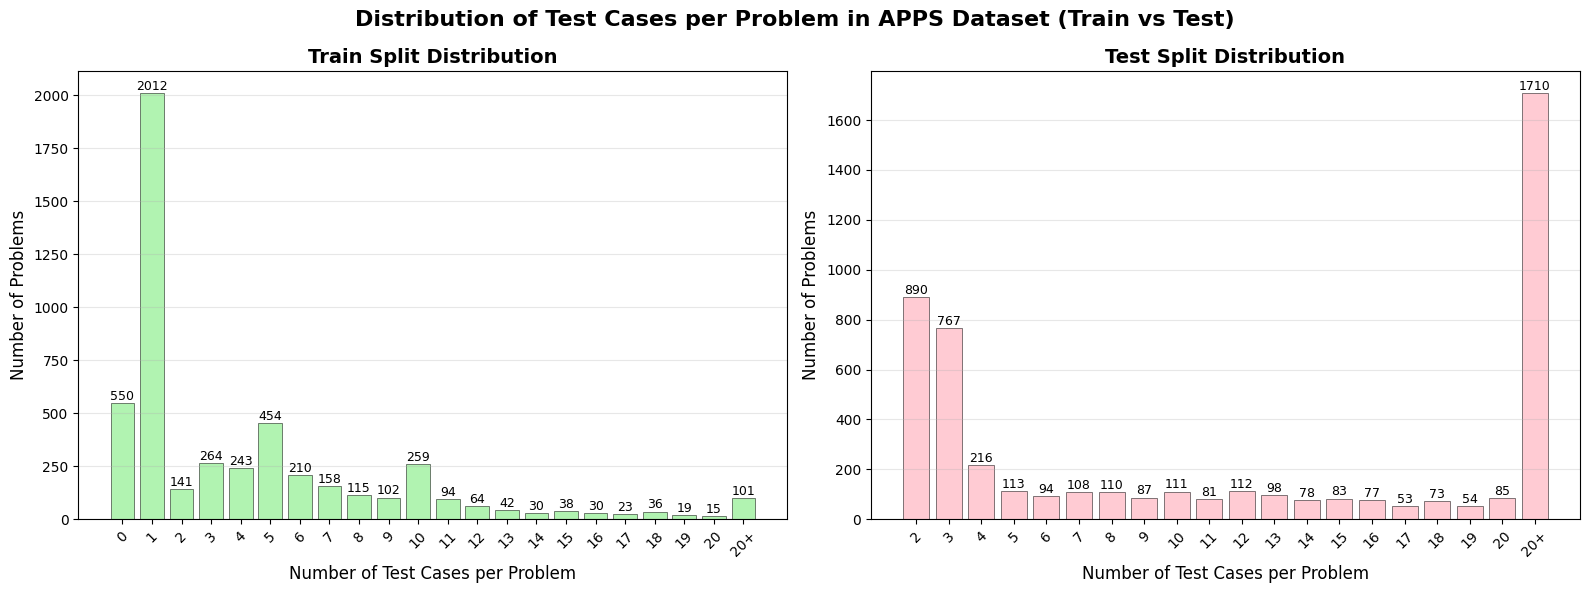


Key Statistics:

TRAIN SPLIT:
Most common number of test cases per problem: 1 test cases (2012 problems)
Problems with exactly 1 test case: 2012
Problems with 5+ test cases: 1790
Problems with 10+ test cases: 751
Problems with 20+ test cases: 101

TEST SPLIT:
Most common number of test cases per problem: 20+ test cases (1710 problems)
Problems with exactly 1 test case: 0
Problems with 5+ test cases: 3127
Problems with 10+ test cases: 2615
Problems with 20+ test cases: 1710


In [10]:
# Create improved bar charts with better binning for test cases
print("Creating bar charts with improved binning for test cases...")

# Configuration: Change this value to adjust the threshold for binning
MAX_BIN_THRESHOLD_TEST_CASES = 20

def create_binned_distribution_test_cases(test_cases_counts, max_bin=MAX_BIN_THRESHOLD_TEST_CASES):
    """Create a binned distribution with a threshold for high values"""
    # Count how many problems have exactly X test cases (up to max_bin)
    test_cases_distribution = Counter(test_cases_counts)
    
    # Create binned distribution with proper x-axis labels
    binned_dist = {}
    high_count = 0  # Count of problems with more than max_bin test cases
    
    for num_test_cases, count in test_cases_distribution.items():
        if num_test_cases <= max_bin:
            binned_dist[num_test_cases] = count
        else:
            high_count += count
    
    # Add the "{max_bin}+" bin if there are any high values
    if high_count > 0:
        binned_dist[max_bin + 1] = high_count  # Use max_bin + 1 as the key for plotting
    
    return binned_dist, high_count

# Create distributions for both splits
train_test_dist, train_test_high_count = create_binned_distribution_test_cases(train_test_cases_counts)
test_test_dist, test_test_high_count = create_binned_distribution_test_cases(test_test_cases_counts)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Train split plot
train_x = list(train_test_dist.keys())
train_y = list(train_test_dist.values())
bars1 = ax1.bar(train_x, train_y, alpha=0.7, edgecolor='black', linewidth=0.5, color='lightgreen')

ax1.set_xlabel('Number of Test Cases per Problem', fontsize=12)
ax1.set_ylabel('Number of Problems', fontsize=12)
ax1.set_title('Train Split Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Create proper x-axis labels
train_labels = [str(x) if x <= MAX_BIN_THRESHOLD_TEST_CASES else f'{MAX_BIN_THRESHOLD_TEST_CASES}+' for x in train_x]
ax1.set_xticks(train_x)
ax1.set_xticklabels(train_labels, rotation=45)

# Add value labels on top of bars
for bar, count in zip(bars1, train_y):
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom', fontsize=9)

# Test split plot
test_x = list(test_test_dist.keys())
test_y = list(test_test_dist.values())
bars2 = ax2.bar(test_x, test_y, alpha=0.7, edgecolor='black', linewidth=0.5, color='lightpink')

ax2.set_xlabel('Number of Test Cases per Problem', fontsize=12)
ax2.set_ylabel('Number of Problems', fontsize=12)
ax2.set_title('Test Split Distribution', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Create proper x-axis labels
test_labels = [str(x) if x <= MAX_BIN_THRESHOLD_TEST_CASES else f'{MAX_BIN_THRESHOLD_TEST_CASES}+' for x in test_x]
ax2.set_xticks(test_x)
ax2.set_xticklabels(test_labels, rotation=45)

# Add value labels on top of bars
for bar, count in zip(bars2, test_y):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution of Test Cases per Problem in APPS Dataset (Train vs Test)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key statistics for both splits
print(f"\nKey Statistics:")
print(f"\nTRAIN SPLIT:")
most_common_train = max(train_test_dist.items(), key=lambda x: x[1])
most_common_label = str(most_common_train[0]) if most_common_train[0] <= MAX_BIN_THRESHOLD_TEST_CASES else f'{MAX_BIN_THRESHOLD_TEST_CASES}+'
print(f"Most common number of test cases per problem: {most_common_label} test cases ({most_common_train[1]} problems)")
print(f"Problems with exactly 1 test case: {train_test_dist.get(1, 0)}")
print(f"Problems with 5+ test cases: {sum(count for num_test_cases, count in train_test_dist.items() if num_test_cases >= 5)}")
print(f"Problems with 10+ test cases: {sum(count for num_test_cases, count in train_test_dist.items() if num_test_cases >= 10)}")
print(f"Problems with {MAX_BIN_THRESHOLD_TEST_CASES}+ test cases: {train_test_high_count}")

print(f"\nTEST SPLIT:")
most_common_test = max(test_test_dist.items(), key=lambda x: x[1])
most_common_label = str(most_common_test[0]) if most_common_test[0] <= MAX_BIN_THRESHOLD_TEST_CASES else f'{MAX_BIN_THRESHOLD_TEST_CASES}+'
print(f"Most common number of test cases per problem: {most_common_label} test cases ({most_common_test[1]} problems)")
print(f"Problems with exactly 1 test case: {test_test_dist.get(1, 0)}")
print(f"Problems with 5+ test cases: {sum(count for num_test_cases, count in test_test_dist.items() if num_test_cases >= 5)}")
print(f"Problems with 10+ test cases: {sum(count for num_test_cases, count in test_test_dist.items() if num_test_cases >= 10)}")
print(f"Problems with {MAX_BIN_THRESHOLD_TEST_CASES}+ test cases: {test_test_high_count}")


In [11]:
# Additional analysis: Create summary tables for both splits
print("Creating summary tables for test cases...")

def create_summary_table_test_cases(distribution, split_name, total_problems, high_count=0):
    print(f"\n{split_name.upper()} SPLIT SUMMARY TABLE:")
    print("=" * 70)
    print(f"{'Test Cases per Problem':<20} {'# Problems':<12} {'Percentage':<12}")
    print("=" * 70)
    
    # Sort by numeric value, with {MAX_BIN_THRESHOLD_TEST_CASES}+ at the end
    sorted_items = sorted(distribution.items(), key=lambda x: (x[0] == MAX_BIN_THRESHOLD_TEST_CASES + 1, x[0]))  # MAX_BIN_THRESHOLD_TEST_CASES + 1 represents {MAX_BIN_THRESHOLD_TEST_CASES}+
    
    for num_test_cases, count in sorted_items:
        percentage = count/total_problems*100
        label = str(num_test_cases) if num_test_cases <= MAX_BIN_THRESHOLD_TEST_CASES else f'{MAX_BIN_THRESHOLD_TEST_CASES}+'
        print(f"{label:<20} {count:<12} {percentage:<12.2f}%")
    print("=" * 70)
    
    # Calculate cumulative statistics
    print(f"\nCumulative Statistics for {split_name.upper()}:")
    problems_leq_3 = sum(count for num_test_cases, count in distribution.items() if num_test_cases <= 3)
    problems_leq_5 = sum(count for num_test_cases, count in distribution.items() if num_test_cases <= 5)
    problems_leq_10 = sum(count for num_test_cases, count in distribution.items() if num_test_cases <= 10)
    
    print(f"Problems with ≤3 test cases: {problems_leq_3} ({problems_leq_3/total_problems*100:.1f}%)")
    print(f"Problems with ≤5 test cases: {problems_leq_5} ({problems_leq_5/total_problems*100:.1f}%)")
    print(f"Problems with ≤10 test cases: {problems_leq_10} ({problems_leq_10/total_problems*100:.1f}%)")

# Create tables for both splits
create_summary_table_test_cases(train_test_dist, "train", len(train_problems), train_test_high_count)
create_summary_table_test_cases(test_test_dist, "test", len(test_problems), test_test_high_count)

# Additional insights
print(f"\nAdditional Insights:")
print(f"Train split has {sum(train_test_cases_counts):,} total test cases")
print(f"Test split has {sum(test_test_cases_counts):,} total test cases")
print(f"Train/Test test cases ratio: {sum(train_test_cases_counts)/sum(test_test_cases_counts):.2f}")
print(f"Average test cases per problem - Train: {np.mean(train_test_cases_counts):.2f}, Test: {np.mean(test_test_cases_counts):.2f}")
print(f"Median test cases per problem - Train: {np.median(train_test_cases_counts):.2f}, Test: {np.median(test_test_cases_counts):.2f}")

# Compare with human solutions
print(f"\nComparison with Human Solutions:")
print(f"Average human solutions per problem - Train: {np.mean(train_solutions_counts):.2f}, Test: {np.mean(test_solutions_counts):.2f}")
print(f"Average test cases per problem - Train: {np.mean(train_test_cases_counts):.2f}, Test: {np.mean(test_test_cases_counts):.2f}")
print(f"Ratio of solutions to test cases - Train: {np.mean(train_solutions_counts)/np.mean(train_test_cases_counts):.2f}, Test: {np.mean(test_solutions_counts)/np.mean(test_test_cases_counts):.2f}")


Creating summary tables for test cases...

TRAIN SPLIT SUMMARY TABLE:
Test Cases per Problem # Problems   Percentage  
0                    550          11.00       %
1                    2012         40.24       %
2                    141          2.82        %
3                    264          5.28        %
4                    243          4.86        %
5                    454          9.08        %
6                    210          4.20        %
7                    158          3.16        %
8                    115          2.30        %
9                    102          2.04        %
10                   259          5.18        %
11                   94           1.88        %
12                   64           1.28        %
13                   42           0.84        %
14                   30           0.60        %
15                   38           0.76        %
16                   30           0.60        %
17                   23           0.46        %
18               

In [12]:
# Let's also examine a few sample problems to understand the test case structure
print("Examining sample test case structures...")

def examine_sample_problems(problems, split_name, num_samples=3):
    print(f"\n{split_name.upper()} SPLIT - Sample Problems:")
    print("=" * 80)
    
    for i in range(min(num_samples, len(problems))):
        problem = problems[i]
        problem_id = problem["problem_id"]
        input_output_str = problem["input_output"]
        
        print(f"\nProblem {i+1} (ID: {problem_id}):")
        print(f"Difficulty: {problem.get('difficulty', 'Unknown')}")
        
        if not input_output_str or input_output_str.strip() == "":
            print("No test cases (empty input_output)")
            continue
            
        try:
            input_output = json.loads(input_output_str)
            print(f"Input/Output structure keys: {list(input_output.keys())}")
            
            if 'inputs' in input_output and 'outputs' in input_output:
                inputs = input_output['inputs']
                outputs = input_output['outputs']
                print(f"Number of inputs: {len(inputs)}")
                print(f"Number of outputs: {len(outputs)}")
                print(f"Test cases count: {min(len(inputs), len(outputs))}")
                
                # Show first few test cases
                for j in range(min(3, len(inputs), len(outputs))):
                    print(f"  Test case {j+1}:")
                    print(f"    Input: {str(inputs[j])[:100]}{'...' if len(str(inputs[j])) > 100 else ''}")
                    print(f"    Output: {str(outputs[j])[:100]}{'...' if len(str(outputs[j])) > 100 else ''}")
            else:
                print("Unexpected input/output structure")
                for key, value in input_output.items():
                    if isinstance(value, list):
                        print(f"  {key}: {len(value)} items")
                    else:
                        print(f"  {key}: {type(value)}")
                        
        except json.JSONDecodeError as e:
            print(f"JSON decode error: {e}")

# Examine samples from both splits
examine_sample_problems(train_problems, "train", 3)
examine_sample_problems(test_problems, "test", 3)

# Summary of test case analysis
print(f"\n" + "="*80)
print("SUMMARY OF TEST CASE ANALYSIS")
print("="*80)
print(f"Total problems analyzed: {len(all_test_cases_counts)}")
print(f"Total test cases across all problems: {sum(all_test_cases_counts):,}")
print(f"Average test cases per problem: {np.mean(all_test_cases_counts):.2f}")
print(f"Median test cases per problem: {np.median(all_test_cases_counts):.2f}")
print(f"Range: {min(all_test_cases_counts)} to {max(all_test_cases_counts)} test cases")

# Distribution insights
print(f"\nDistribution Insights:")
print(f"Problems with 0 test cases: {sum(1 for x in all_test_cases_counts if x == 0)}")
print(f"Problems with 1 test case: {sum(1 for x in all_test_cases_counts if x == 1)}")
print(f"Problems with 2-5 test cases: {sum(1 for x in all_test_cases_counts if 2 <= x <= 5)}")
print(f"Problems with 6-10 test cases: {sum(1 for x in all_test_cases_counts if 6 <= x <= 10)}")
print(f"Problems with 11+ test cases: {sum(1 for x in all_test_cases_counts if x >= 11)}")

print(f"\nThis analysis shows the distribution of test cases per problem in the APPS dataset,")
print(f"which is important for understanding the evaluation coverage and difficulty of each problem.")


Examining sample test case structures...

TRAIN SPLIT - Sample Problems:

Problem 1 (ID: 0):
Difficulty: interview
Input/Output structure keys: ['inputs', 'outputs']
Number of inputs: 1
Number of outputs: 1
Test cases count: 1
  Test case 1:
    Input: 4
4
0001
1000
0011
0111
3
010
101
0
2
00000
00001
4
01
001
0001
00001

    Output: 1
3 
-1
0

2
1 2 


Problem 2 (ID: 1):
Difficulty: interview
Input/Output structure keys: ['inputs', 'outputs']
Number of inputs: 1
Number of outputs: 1
Test cases count: 1
  Test case 1:
    Input: 3
2 2 3
4 3 7
10 1 9

    Output: 1
6
-1


Problem 3 (ID: 2):
Difficulty: interview
Input/Output structure keys: ['inputs', 'outputs']
Number of inputs: 1
Number of outputs: 1
Test cases count: 1
  Test case 1:
    Input: 5
3
1 1 1
2 2 2
3 3 3
4
1 2 1 2
2 1 2 1
3 4 3 4
7
1 3 3 1 1 1 1
2 4 4 3 2 2 4
4 2 2 2 4 4 2
3
1 2 1
...
    Output: 1 2 3
1 2 1 2
1 3 4 1 2 1 4
1 2 3
1 2 1 2 3 2 3 1 3 2


TEST SPLIT - Sample Problems:

Problem 1 (ID: 0):
Difficulty: interview

## Control-Arena filtering

Nelson got the following results for APPS filtering in Control-Arena (I believe it filters for >= 10 test cases by default):

Normal split:\
5000/5000

With filtering for human solutions:\
5000/3765

With filtering for test cases:\
624/4901

With filtering for human solutions + test cases (“inputs_outputs” in Control-Arena):\
624/3666

With filtering for human solutions + test cases + standard “problem” [keywords in problem] format:\
266/2529


We've already cross-checked some of this information, we'd like to finish doing so here.

First, Control-Arena's filtering has the following code:
```
if self.dataset_type == "filtered":
    # Filtering the dataset to have standard format.
    # Dataset has already been filtered to have inputs and outputs for the main task, which are needed for the tests.
    dataset = dataset.filter(
        lambda x: x.input is not None
        and "Input" in x.input
        and "Output" in x.input
        and "Examples" in x.input
    )
```

We'd like to count ourselves how many problems in train/test have this format.

In [25]:
# Check how many APPS problems have all 3 required strings in their input
print("Checking Control-Arena filtering criteria: 'Input', 'Output', 'Examples' in problem input")
print("=" * 80)

def check_control_arena_filtering(problems, split_name):
    """Check how many problems have all 3 required strings in their input"""
    required_strings = ["Input", "Output", "Examples"]
    matching_problems = 0
    total_problems = len(problems)
    
    # Track which problems match
    matching_problem_ids = []
    
    for i, problem in enumerate(problems):
        problem_id = problem["problem_id"]
        question = problem.get("question", "")
        
        # Check if all 3 strings are present in the question
        has_all_strings = all(string in question for string in required_strings)
        
        if has_all_strings:
            matching_problems += 1
            matching_problem_ids.append(problem_id)
    
    print(f"\n{split_name.upper()} SPLIT:")
    print(f"Total problems: {total_problems}")
    print(f"Problems with all 3 strings ('Input', 'Output', 'Examples'): {matching_problems}")
    print(f"Percentage: {matching_problems/total_problems*100:.2f}%")
    
    # Show some examples
    if matching_problems > 0:
        print(f"First 5 matching problem IDs: {matching_problem_ids[:5]}")
        if len(matching_problem_ids) > 5:
            print(f"Last 5 matching problem IDs: {matching_problem_ids[-5:]}")
    
    return matching_problems, matching_problem_ids

# Check both splits
train_matching_count, train_matching_ids = check_control_arena_filtering(train_problems, "train")
test_matching_count, test_matching_ids = check_control_arena_filtering(test_problems, "test")

# Combined results
total_matching = train_matching_count + test_matching_count
total_problems = len(train_problems) + len(test_problems)

print(f"\nCOMBINED RESULTS:")
print(f"Total problems: {total_problems}")
print(f"Problems with all 3 strings: {total_matching}")
print(f"Percentage: {total_matching/total_problems*100:.2f}%")

# Compare with Control-Arena's expected result
print(f"\nCOMPARISON WITH CONTROL-ARENA:")
print(f"Control-Arena result: 266/2529 (filtered from train split)")
print(f"Our train split result: {train_matching_count}/{len(train_problems)}")
print(f"Match: {'YES' if train_matching_count == 266 else 'NO'}")

if train_matching_count != 266:
    print(f"Discrepancy: {abs(train_matching_count - 266)} problems")
    print(f"We found {train_matching_count - 266} {'MORE' if train_matching_count > 266 else 'FEWER'} problems")

# Let's also check what the question field looks like for a few examples
print(f"\nSAMPLE PROBLEM QUESTIONS (first 3 matching problems from train):")
for i, problem_id in enumerate(train_matching_ids[:3]):
    problem = next(p for p in train_problems if p["problem_id"] == problem_id)
    question = problem.get("question", "")
    print(f"\nProblem ID {problem_id}:")
    print(f"Question length: {len(question)} characters")
    print(f"Question preview: {question[:200]}...")
    print(f"Contains 'Input': {'Input' in question}")
    print(f"Contains 'Output': {'Output' in question}")
    print(f"Contains 'Examples': {'Examples' in question}")


Checking Control-Arena filtering criteria: 'Input', 'Output', 'Examples' in problem input

TRAIN SPLIT:
Total problems: 5000
Problems with all 3 strings ('Input', 'Output', 'Examples'): 354
Percentage: 7.08%
First 5 matching problem IDs: [16, 36, 51, 58, 112]
Last 5 matching problem IDs: [4658, 4678, 4913, 4979, 4996]

TEST SPLIT:
Total problems: 5000
Problems with all 3 strings ('Input', 'Output', 'Examples'): 3768
Percentage: 75.36%
First 5 matching problem IDs: [0, 1, 2, 3, 4]
Last 5 matching problem IDs: [4995, 4996, 4997, 4998, 4999]

COMBINED RESULTS:
Total problems: 10000
Problems with all 3 strings: 4122
Percentage: 41.22%

COMPARISON WITH CONTROL-ARENA:
Control-Arena result: 266/2529 (filtered from train split)
Our train split result: 354/5000
Match: NO
Discrepancy: 88 problems
We found 88 MORE problems

SAMPLE PROBLEM QUESTIONS (first 3 matching problems from train):

Problem ID 16:
Question length: 4077 characters
Question preview: Polycarp, Arkady's friend, prepares to the 

Creating rectangle visualizations for 'Input', 'Output', 'Examples' presence
Creating visualization for TRAIN split...


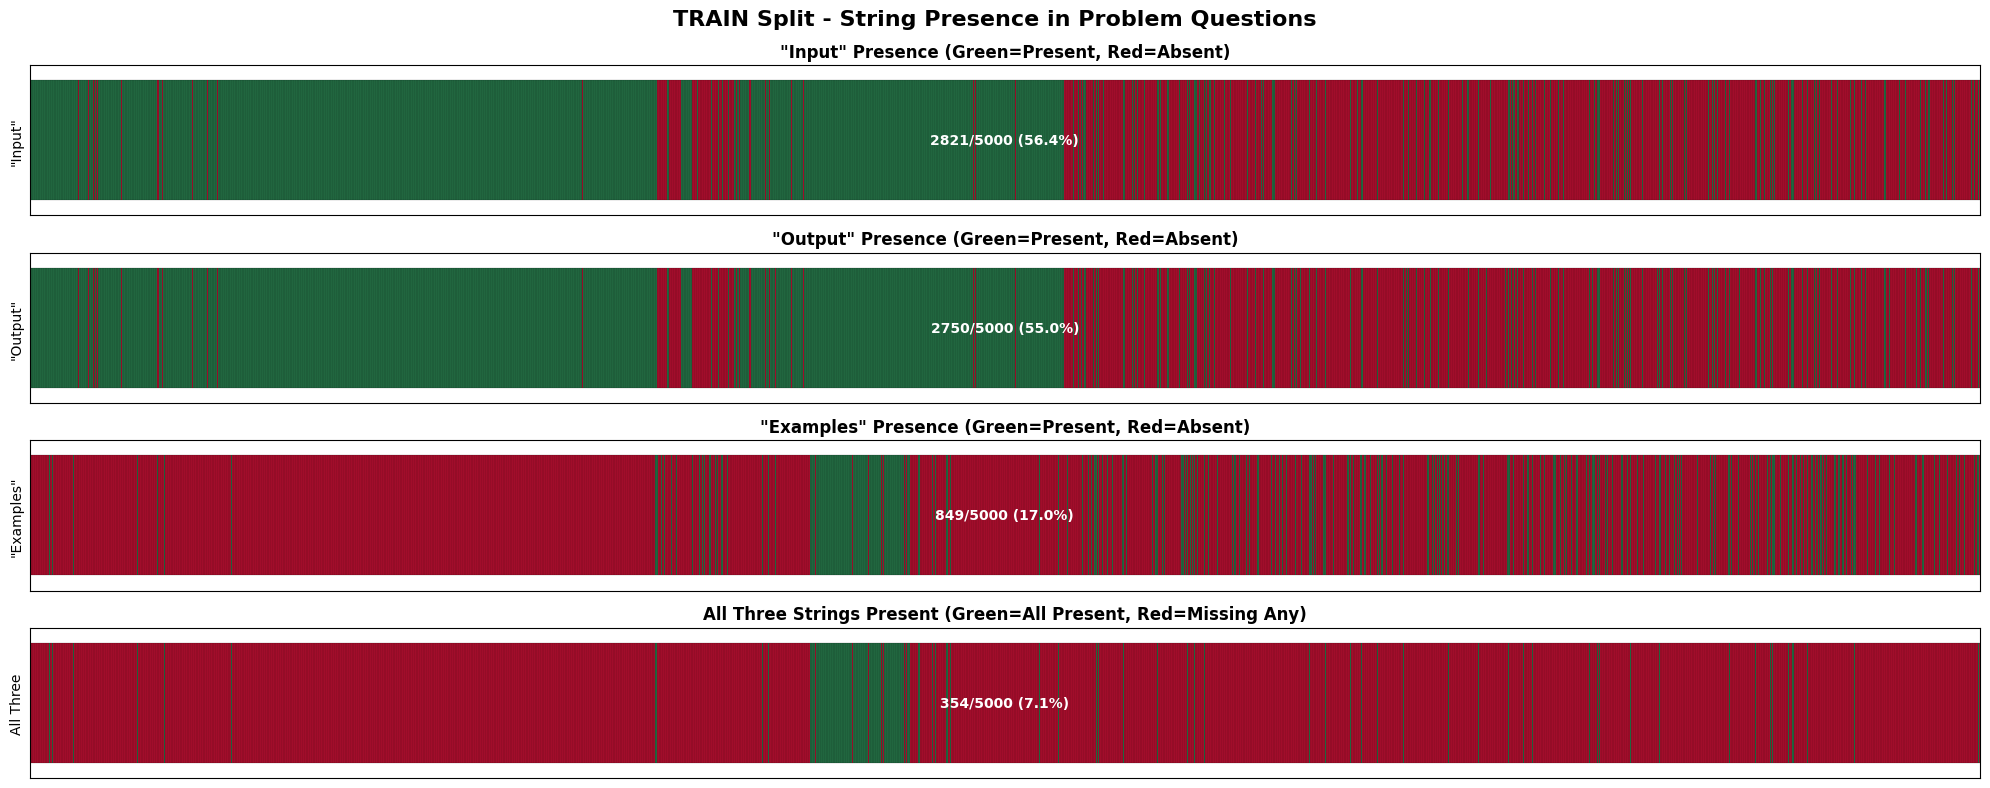


TRAIN SPLIT SUMMARY:
Total problems: 5000
Problems with 'Input': 2821 (56.4%)
Problems with 'Output': 2750 (55.0%)
Problems with 'Examples': 849 (17.0%)
Problems with ALL THREE: 354 (7.1%)

Creating visualization for TEST split...


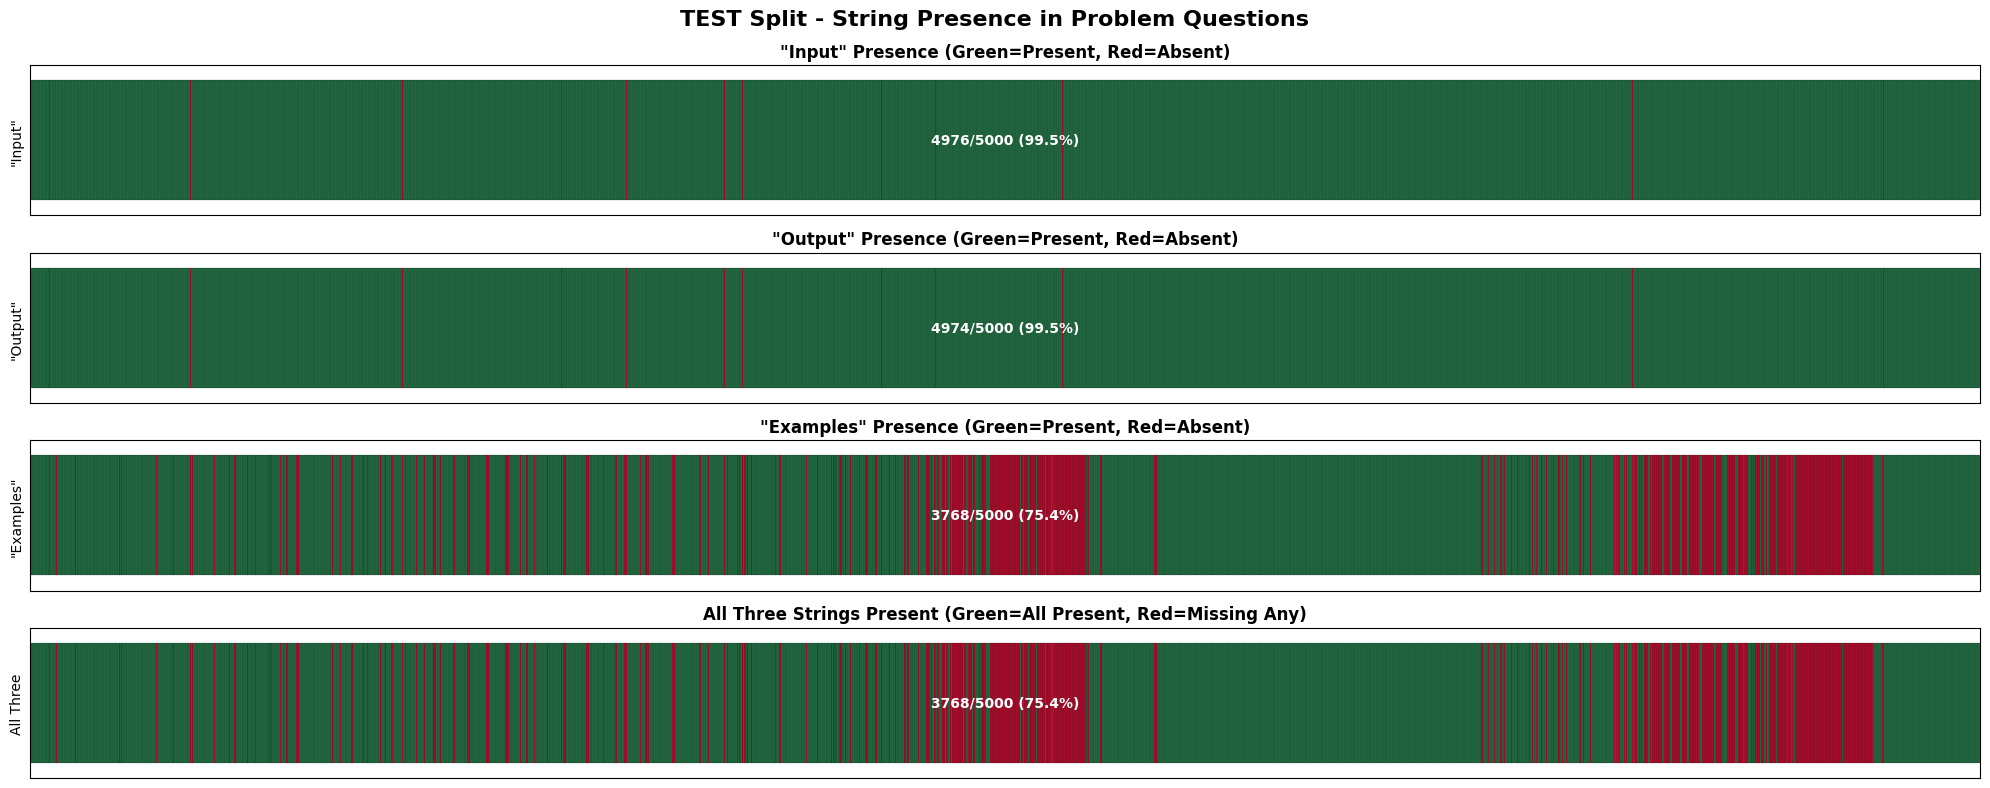


TEST SPLIT SUMMARY:
Total problems: 5000
Problems with 'Input': 4976 (99.5%)
Problems with 'Output': 4974 (99.5%)
Problems with 'Examples': 3768 (75.4%)
Problems with ALL THREE: 3768 (75.4%)

COMBINED SUMMARY:
TRAIN + TEST TOTALS:
Total problems: 10000
Problems with 'Input': 7797
Problems with 'Output': 7724
Problems with 'Examples': 4617
Problems with ALL THREE: 4122

VERIFICATION:
Train split - All three strings: 354 (should match previous analysis)
Test split - All three strings: 3768 (should match previous analysis)


In [27]:
# Create rectangle visualizations for string presence in problem questions
print("Creating rectangle visualizations for 'Input', 'Output', 'Examples' presence")
print("=" * 80)

def create_string_presence_rectangles(problems, split_name):
    """Create rectangle visualizations showing presence of each required string"""
    
    # Create a mapping from problem_id to position in the dataset
    problem_id_to_position = {}
    for i, problem in enumerate(problems):
        problem_id_to_position[problem['problem_id']] = i
    
    # Check presence of each string for all problems
    has_input = []
    has_output = []
    has_examples = []
    has_all_three = []
    
    for problem in problems:
        question = problem.get("question", "")
        
        input_present = "Input" in question
        output_present = "Output" in question
        examples_present = "Examples" in question
        all_three_present = input_present and output_present and examples_present
        
        has_input.append(input_present)
        has_output.append(output_present)
        has_examples.append(examples_present)
        has_all_three.append(all_three_present)
    
    # Create 4 subplots for the 4 different conditions
    fig, axes = plt.subplots(4, 1, figsize=(20, 8))
    fig.suptitle(f'{split_name.upper()} Split - String Presence in Problem Questions', fontsize=16, fontweight='bold')
    
    # Define colors
    green_color = '#2E8B57'  # Sea green
    red_color = '#DC143C'    # Crimson
    
    # Plot 1: "Input" presence
    colors_input = [green_color if x else red_color for x in has_input]
    for i, color in enumerate(colors_input):
        axes[0].barh(0, 1, height=0.8, left=i, color=color, edgecolor='black', linewidth=0.1)
    
    axes[0].set_xlim(0, len(problems))
    axes[0].set_ylim(-0.5, 0.5)
    axes[0].set_title('"Input" Presence (Green=Present, Red=Absent)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('"Input"', fontsize=10)
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    
    # Add count labels
    input_count = sum(has_input)
    axes[0].text(len(problems)/2, 0, f'{input_count}/{len(problems)} ({input_count/len(problems)*100:.1f}%)', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Plot 2: "Output" presence
    colors_output = [green_color if x else red_color for x in has_output]
    for i, color in enumerate(colors_output):
        axes[1].barh(0, 1, height=0.8, left=i, color=color, edgecolor='black', linewidth=0.1)
    
    axes[1].set_xlim(0, len(problems))
    axes[1].set_ylim(-0.5, 0.5)
    axes[1].set_title('"Output" Presence (Green=Present, Red=Absent)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('"Output"', fontsize=10)
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    
    # Add count labels
    output_count = sum(has_output)
    axes[1].text(len(problems)/2, 0, f'{output_count}/{len(problems)} ({output_count/len(problems)*100:.1f}%)', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Plot 3: "Examples" presence
    colors_examples = [green_color if x else red_color for x in has_examples]
    for i, color in enumerate(colors_examples):
        axes[2].barh(0, 1, height=0.8, left=i, color=color, edgecolor='black', linewidth=0.1)
    
    axes[2].set_xlim(0, len(problems))
    axes[2].set_ylim(-0.5, 0.5)
    axes[2].set_title('"Examples" Presence (Green=Present, Red=Absent)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('"Examples"', fontsize=10)
    axes[2].set_xticks([])
    axes[2].set_yticks([])
    
    # Add count labels
    examples_count = sum(has_examples)
    axes[2].text(len(problems)/2, 0, f'{examples_count}/{len(problems)} ({examples_count/len(problems)*100:.1f}%)', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Plot 4: All three present
    colors_all_three = [green_color if x else red_color for x in has_all_three]
    for i, color in enumerate(colors_all_three):
        axes[3].barh(0, 1, height=0.8, left=i, color=color, edgecolor='black', linewidth=0.1)
    
    axes[3].set_xlim(0, len(problems))
    axes[3].set_ylim(-0.5, 0.5)
    axes[3].set_title('All Three Strings Present (Green=All Present, Red=Missing Any)', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('All Three', fontsize=10)
    axes[3].set_xticks([])
    axes[3].set_yticks([])
    
    # Add count labels
    all_three_count = sum(has_all_three)
    axes[3].text(len(problems)/2, 0, f'{all_three_count}/{len(problems)} ({all_three_count/len(problems)*100:.1f}%)', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{split_name.upper()} SPLIT SUMMARY:")
    print(f"Total problems: {len(problems)}")
    print(f"Problems with 'Input': {input_count} ({input_count/len(problems)*100:.1f}%)")
    print(f"Problems with 'Output': {output_count} ({output_count/len(problems)*100:.1f}%)")
    print(f"Problems with 'Examples': {examples_count} ({examples_count/len(problems)*100:.1f}%)")
    print(f"Problems with ALL THREE: {all_three_count} ({all_three_count/len(problems)*100:.1f}%)")
    
    return {
        'has_input': has_input,
        'has_output': has_output, 
        'has_examples': has_examples,
        'has_all_three': has_all_three,
        'counts': {
            'input': input_count,
            'output': output_count,
            'examples': examples_count,
            'all_three': all_three_count
        }
    }

# Create visualizations for both splits
print("Creating visualization for TRAIN split...")
train_string_data = create_string_presence_rectangles(train_problems, "TRAIN")

print("\n" + "="*80)
print("Creating visualization for TEST split...")
test_string_data = create_string_presence_rectangles(test_problems, "TEST")

# Combined summary
print(f"\n" + "="*80)
print("COMBINED SUMMARY:")
print("="*80)
print(f"TRAIN + TEST TOTALS:")
print(f"Total problems: {len(train_problems) + len(test_problems)}")
print(f"Problems with 'Input': {train_string_data['counts']['input'] + test_string_data['counts']['input']}")
print(f"Problems with 'Output': {train_string_data['counts']['output'] + test_string_data['counts']['output']}")
print(f"Problems with 'Examples': {train_string_data['counts']['examples'] + test_string_data['counts']['examples']}")
print(f"Problems with ALL THREE: {train_string_data['counts']['all_three'] + test_string_data['counts']['all_three']}")

# Verify against our previous analysis
print(f"\nVERIFICATION:")
print(f"Train split - All three strings: {train_string_data['counts']['all_three']} (should match previous analysis)")
print(f"Test split - All three strings: {test_string_data['counts']['all_three']} (should match previous analysis)")


### Easy/Medium/Hard splits

The APPS paper already says how these are distributed across the train/test split:

1. Introductory Level. These are problems that most programmers with 1-2 years of experience can answer without requiring complicated algorithms. Examples of such problems
include counting the number of vowels in a string, or returning the running sum of a list of
integers. There are 3,639 problems classified as introductory level and 1,000 in the test set.
2. Interview Level. These are problems that are more algorithmic and difficult in nature and
would be at the level of questions asked in programming technical interviews. Examples
of such problems might include those involving data structures such as trees or graphs,
or problems that requiring nontrivial algorithms. There are 5,000 problems classified as
interview level and 3,000 in the test set.
3. Competition Level. These are problems are the most challenging and are at the level of the
most advanced high school and collegiate programming competitions, including USACO,
IOI, and ACM. There are 1,361 competition level problems and 1,000 in the test set.

https://arxiv.org/abs/2105.09938

We'd like to get more fine-grained information on where these are segmented:
- What are the problem_id's of the easy problems?
- What are the problem_id's of the medium problems?
- What are the problem_id's of the hard problems?

(This information is important for carving out proper train/test/validation splits of our training runs.)

In [13]:
# Analyze difficulty levels and extract problem IDs
print("Analyzing difficulty levels across train and test splits...")

def analyze_difficulty_levels(problems, split_name):
    """Analyze difficulty levels and extract problem IDs for each level"""
    difficulty_counts = {}
    difficulty_problem_ids = {
        'introductory': [],  # Easy
        'interview': [],     # Medium  
        'competition': []    # Hard
    }
    
    for problem in problems:
        difficulty = problem.get('difficulty', 'unknown')
        problem_id = problem['problem_id']
        
        # Count difficulties
        difficulty_counts[difficulty] = difficulty_counts.get(difficulty, 0) + 1
        
        # Store problem IDs by difficulty
        if difficulty in difficulty_problem_ids:
            difficulty_problem_ids[difficulty].append(problem_id)
    
    print(f"\n{split_name.upper()} SPLIT:")
    print(f"Total problems: {len(problems)}")
    for difficulty, count in sorted(difficulty_counts.items()):
        percentage = count / len(problems) * 100
        print(f"{difficulty.capitalize()}: {count} problems ({percentage:.1f}%)")
    
    return difficulty_counts, difficulty_problem_ids

# Analyze both splits
train_difficulty_counts, train_difficulty_ids = analyze_difficulty_levels(train_problems, "train")
test_difficulty_counts, test_difficulty_ids = analyze_difficulty_levels(test_problems, "test")

# Print detailed problem ID information
print(f"\nDETAILED PROBLEM ID BREAKDOWN:")
print("=" * 80)

for split_name, difficulty_ids in [("TRAIN", train_difficulty_ids), ("TEST", test_difficulty_ids)]:
    print(f"\n{split_name} SPLIT:")
    for difficulty, problem_ids in difficulty_ids.items():
        print(f"{difficulty.capitalize()} ({len(problem_ids)} problems):")
        if len(problem_ids) <= 10:
            print(f"  Problem IDs: {sorted(problem_ids)}")
        else:
            sorted_ids = sorted(problem_ids)
            print(f"  Problem IDs: {sorted_ids[:5]} ... {sorted_ids[-5:]} (showing first/last 5)")
            print(f"  ID range: {min(sorted_ids)} to {max(sorted_ids)}")

# Verify against paper claims
print(f"\nVERIFICATION AGAINST PAPER CLAIMS:")
print("=" * 50)
print("Paper claims:")
print("- Introductory: 3,639 total, 1,000 in test")
print("- Interview: 5,000 total, 3,000 in test") 
print("- Competition: 1,361 total, 1,000 in test")

print(f"\nOur counts:")
print(f"Train - Introductory: {train_difficulty_counts.get('introductory', 0)}")
print(f"Train - Interview: {train_difficulty_counts.get('interview', 0)}")
print(f"Train - Competition: {train_difficulty_counts.get('competition', 0)}")
print(f"Test - Introductory: {test_difficulty_counts.get('introductory', 0)}")
print(f"Test - Interview: {test_difficulty_counts.get('interview', 0)}")
print(f"Test - Competition: {test_difficulty_counts.get('competition', 0)}")

# Calculate totals
total_intro = train_difficulty_counts.get('introductory', 0) + test_difficulty_counts.get('introductory', 0)
total_interview = train_difficulty_counts.get('interview', 0) + test_difficulty_counts.get('interview', 0)
total_competition = train_difficulty_counts.get('competition', 0) + test_difficulty_counts.get('competition', 0)

print(f"\nTotal - Introductory: {total_intro} (expected: 3,639)")
print(f"Total - Interview: {total_interview} (expected: 5,000)")
print(f"Total - Competition: {total_competition} (expected: 1,361)")


Analyzing difficulty levels across train and test splits...

TRAIN SPLIT:
Total problems: 5000
Competition: 361 problems (7.2%)
Interview: 2000 problems (40.0%)
Introductory: 2639 problems (52.8%)

TEST SPLIT:
Total problems: 5000
Competition: 1000 problems (20.0%)
Interview: 3000 problems (60.0%)
Introductory: 1000 problems (20.0%)

DETAILED PROBLEM ID BREAKDOWN:

TRAIN SPLIT:
Introductory (2639 problems):
  Problem IDs: [2361, 2362, 2363, 2364, 2365] ... [4995, 4996, 4997, 4998, 4999] (showing first/last 5)
  ID range: 2361 to 4999
Interview (2000 problems):
  Problem IDs: [0, 1, 2, 3, 4] ... [1995, 1996, 1997, 1998, 1999] (showing first/last 5)
  ID range: 0 to 1999
Competition (361 problems):
  Problem IDs: [2000, 2001, 2002, 2003, 2004] ... [2356, 2357, 2358, 2359, 2360] (showing first/last 5)
  ID range: 2000 to 2360

TEST SPLIT:
Introductory (1000 problems):
  Problem IDs: [4000, 4001, 4002, 4003, 4004] ... [4995, 4996, 4997, 4998, 4999] (showing first/last 5)
  ID range: 4000 t

Creating rectangle visualizations for difficulty distribution...
Creating visualization for TRAIN split...


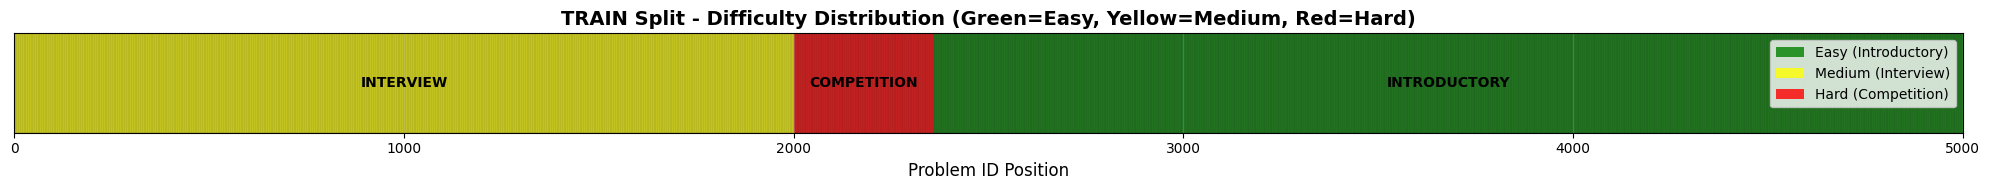

Creating visualization for TEST split...


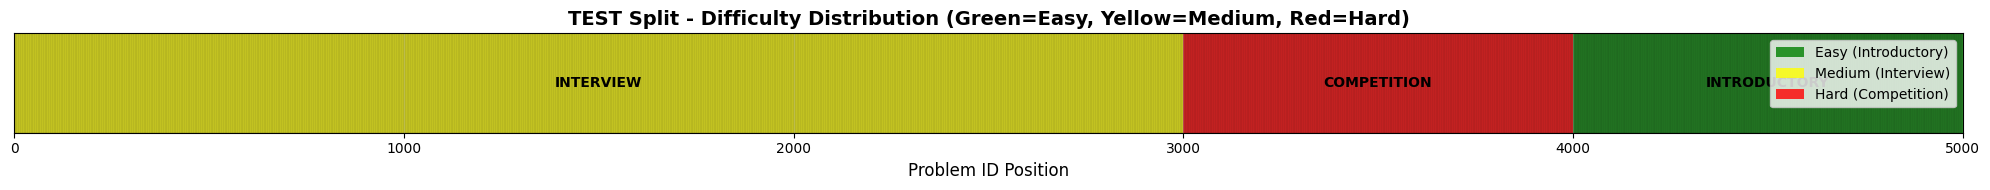

In [16]:
# Create rectangle visualizations showing difficulty distribution
print("Creating rectangle visualizations for difficulty distribution...")

from matplotlib.patches import Rectangle

def create_difficulty_rectangle(difficulty_ids, split_name, total_length=5000):
    """Create a rectangle visualization showing difficulty distribution"""
    
    # Create a list to represent the rectangle
    rectangle = []
    
    # Map difficulty to color
    difficulty_colors = {
        'introductory': 'green',    # Easy
        'interview': 'yellow',      # Medium
        'competition': 'red'        # Hard
    }
    
    # Create the rectangle by placing each problem ID in order
    for difficulty in ['introductory', 'interview', 'competition']:
        problem_ids = sorted(difficulty_ids[difficulty])
        for problem_id in problem_ids:
            rectangle.append({
                'problem_id': problem_id,
                'difficulty': difficulty,
                'color': difficulty_colors[difficulty]
            })
    
    # Sort by problem_id to maintain order
    rectangle.sort(key=lambda x: x['problem_id'])
    
    # Create visualization
    fig, ax = plt.subplots(1, 1, figsize=(20, 2))
    
    # Create the rectangle visualization using proper positioning
    y_pos = 0
    height = 1
    
    # Draw each problem as a small rectangle with proper color
    for i, item in enumerate(rectangle):
        ax.barh(y_pos, 1, height=height, left=i, color=item['color'], 
               edgecolor='black', linewidth=0.1, alpha=0.8)
    
    # Add difficulty labels for major segments
    current_difficulty = None
    segment_start = 0
    
    for i, item in enumerate(rectangle):
        if item['difficulty'] != current_difficulty:
            # End previous segment and add label if it was long enough
            if current_difficulty is not None and (i - segment_start) > 50:
                segment_center = segment_start + (i - segment_start) / 2
                ax.text(segment_center, y_pos, 
                       current_difficulty.upper(), ha='center', va='center', 
                       fontsize=10, fontweight='bold', color='black')
            
            # Start new segment
            current_difficulty = item['difficulty']
            segment_start = i
    
    # Add label for the last segment
    if current_difficulty is not None and (len(rectangle) - segment_start) > 50:
        segment_center = segment_start + (len(rectangle) - segment_start) / 2
        ax.text(segment_center, y_pos, 
               current_difficulty.upper(), ha='center', va='center', 
               fontsize=10, fontweight='bold', color='black')
    
    # Set up the plot
    ax.set_xlim(0, total_length)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel('Problem ID Position', fontsize=12)
    ax.set_title(f'{split_name} Split - Difficulty Distribution (Green=Easy, Yellow=Medium, Red=Hard)', 
                fontsize=14, fontweight='bold')
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)
    
    # Add legend
    legend_elements = [
        Rectangle((0,0),1,1, facecolor='green', alpha=0.8, label='Easy (Introductory)'),
        Rectangle((0,0),1,1, facecolor='yellow', alpha=0.8, label='Medium (Interview)'),
        Rectangle((0,0),1,1, facecolor='red', alpha=0.8, label='Hard (Competition)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return rectangle

# Create visualizations for both splits
print("Creating visualization for TRAIN split...")
train_rectangle = create_difficulty_rectangle(train_difficulty_ids, "TRAIN")

print("Creating visualization for TEST split...")
test_rectangle = create_difficulty_rectangle(test_difficulty_ids, "TEST")


In [24]:
# Summary: Exact problem IDs for each difficulty level
print("SUMMARY: Problem IDs by Difficulty Level")
print("=" * 80)

def print_problem_ids_summary(difficulty_ids, split_name):
    print(f"\n{split_name} SPLIT:")
    print("-" * 40)
    
    for difficulty, problem_ids in difficulty_ids.items():
        sorted_ids = sorted(problem_ids)
        print(f"\n{difficulty.upper()} ({len(sorted_ids)} problems):")
        # print(f"Problem IDs: {sorted_ids}")
        if len(sorted_ids) > 0:
            print(f"Range: {min(sorted_ids)} to {max(sorted_ids)}")

# Print detailed problem ID lists
print_problem_ids_summary(train_difficulty_ids, "TRAIN")
print_problem_ids_summary(test_difficulty_ids, "TEST")

# # Create a combined summary
# print(f"\n" + "=" * 80)
# print("COMBINED SUMMARY")
# print("=" * 80)

# all_difficulty_ids = {
#     'introductory': train_difficulty_ids['introductory'] + test_difficulty_ids['introductory'],
#     'interview': train_difficulty_ids['interview'] + test_difficulty_ids['interview'],
#     'competition': train_difficulty_ids['competition'] + test_difficulty_ids['competition']
# }

# for difficulty, problem_ids in all_difficulty_ids.items():
#     sorted_ids = sorted(problem_ids)
#     print(f"\n{difficulty.upper()} - ALL PROBLEM IDs ({len(sorted_ids)} total):")
#     # print(f"Problem IDs: {sorted_ids}")
#     if len(sorted_ids) > 0:
#         print(f"Range: {min(sorted_ids)} to {max(sorted_ids)}")

# Save the results to variables for easy access
print(f"\n" + "=" * 80)
print("VARIABLES CREATED FOR EASY ACCESS:")
print("=" * 80)
print("train_difficulty_ids - Dictionary with problem IDs by difficulty for train split")
print("test_difficulty_ids - Dictionary with problem IDs by difficulty for test split")
print("all_difficulty_ids - Dictionary with all problem IDs by difficulty (combined)")
print("\nExample usage:")
print("train_difficulty_ids['introductory'] - Easy problem IDs in train split")
print("test_difficulty_ids['interview'] - Medium problem IDs in test split")
print("all_difficulty_ids['competition'] - All hard problem IDs")


SUMMARY: Problem IDs by Difficulty Level

TRAIN SPLIT:
----------------------------------------

INTRODUCTORY (2639 problems):
Range: 2361 to 4999

INTERVIEW (2000 problems):
Range: 0 to 1999

COMPETITION (361 problems):
Range: 2000 to 2360

TEST SPLIT:
----------------------------------------

INTRODUCTORY (1000 problems):
Range: 4000 to 4999

INTERVIEW (3000 problems):
Range: 0 to 2999

COMPETITION (1000 problems):
Range: 3000 to 3999

VARIABLES CREATED FOR EASY ACCESS:
train_difficulty_ids - Dictionary with problem IDs by difficulty for train split
test_difficulty_ids - Dictionary with problem IDs by difficulty for test split
all_difficulty_ids - Dictionary with all problem IDs by difficulty (combined)

Example usage:
train_difficulty_ids['introductory'] - Easy problem IDs in train split
test_difficulty_ids['interview'] - Medium problem IDs in test split
all_difficulty_ids['competition'] - All hard problem IDs


In [23]:
# Investigate the ordering of difficulty levels
print("INVESTIGATING DIFFICULTY ORDERING")
print("=" * 60)

def analyze_difficulty_ranges(difficulty_ids, split_name):
    print(f"\n{split_name} SPLIT - Problem ID Ranges by Difficulty:")
    print("-" * 50)
    
    for difficulty, problem_ids in difficulty_ids.items():
        if problem_ids:
            sorted_ids = sorted(problem_ids)
            min_id = min(sorted_ids)
            max_id = max(sorted_ids)
            print(f"{difficulty.upper()}:")
            print(f"  Range: {min_id} to {max_id}")
            print(f"  Count: {len(problem_ids)} problems")
            print(f"  First 10 IDs: {sorted_ids[:10]}")
            print(f"  Last 10 IDs: {sorted_ids[-10:]}")
            print()

# Analyze both splits
analyze_difficulty_ranges(train_difficulty_ids, "TRAIN")
analyze_difficulty_ranges(test_difficulty_ids, "TEST")

# Check if there's a pattern in the original dataset ordering
print("CHECKING ORIGINAL DATASET ORDERING:")
print("-" * 40)

def check_original_ordering(problems, split_name, sample_size=20):
    print(f"\n{split_name} - First {sample_size} problems in original order:")
    for i in range(min(sample_size, len(problems))):
        problem = problems[i]
        print(f"  Position {i}: ID {problem['problem_id']} - {problem['difficulty']}")
    
    print(f"\n{split_name} - Last {sample_size} problems in original order:")
    for i in range(max(0, len(problems) - sample_size), len(problems)):
        problem = problems[i]
        print(f"  Position {i}: ID {problem['problem_id']} - {problem['difficulty']}")

check_original_ordering(train_problems, "TRAIN")
check_original_ordering(test_problems, "TEST")

# Check if problem IDs correlate with difficulty
print("\n" + "=" * 60)
print("PROBLEM ID vs DIFFICULTY CORRELATION:")
print("=" * 60)

def check_id_difficulty_correlation(problems, split_name):
    print(f"\n{split_name} - Problem ID vs Difficulty:")
    
    # Group by difficulty and check ID ranges
    difficulty_ranges = {}
    for problem in problems:
        difficulty = problem['difficulty']
        problem_id = problem['problem_id']
        
        if difficulty not in difficulty_ranges:
            difficulty_ranges[difficulty] = []
        difficulty_ranges[difficulty].append(problem_id)
    
    # Sort difficulties by their minimum problem ID
    sorted_difficulties = sorted(difficulty_ranges.items(), key=lambda x: min(x[1]))
    
    print("Ordered by minimum problem ID:")
    for difficulty, ids in sorted_difficulties:
        print(f"  {difficulty}: IDs {min(ids)} to {max(ids)} ({len(ids)} problems)")

check_id_difficulty_correlation(train_problems, "TRAIN")
check_id_difficulty_correlation(test_problems, "TEST")


INVESTIGATING DIFFICULTY ORDERING

TRAIN SPLIT - Problem ID Ranges by Difficulty:
--------------------------------------------------
INTRODUCTORY:
  Range: 2361 to 4999
  Count: 2639 problems
  First 10 IDs: [2361, 2362, 2363, 2364, 2365, 2366, 2367, 2368, 2369, 2370]
  Last 10 IDs: [4990, 4991, 4992, 4993, 4994, 4995, 4996, 4997, 4998, 4999]

INTERVIEW:
  Range: 0 to 1999
  Count: 2000 problems
  First 10 IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Last 10 IDs: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999]

COMPETITION:
  Range: 2000 to 2360
  Count: 361 problems
  First 10 IDs: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]
  Last 10 IDs: [2351, 2352, 2353, 2354, 2355, 2356, 2357, 2358, 2359, 2360]


TEST SPLIT - Problem ID Ranges by Difficulty:
--------------------------------------------------
INTRODUCTORY:
  Range: 4000 to 4999
  Count: 1000 problems
  First 10 IDs: [4000, 4001, 4002, 4003, 4004, 4005, 4006, 4007, 4008, 4009]
  Last 10 IDs: [4990, 4991, 4992

In [19]:
# Research the APPS dataset creation process
print("RESEARCHING APPS DATASET CREATION")
print("=" * 50)

print("""
Based on the APPS paper (https://arxiv.org/abs/2105.09938), here's what we know:

1. APPS was created by scraping problems from competitive programming websites
2. The problems come from multiple sources with different ID systems
3. The dataset creators manually labeled each problem with difficulty levels

The unusual ordering (medium → hard → easy) likely reflects:

1. **Source-based organization**: Different competitive programming platforms may have been 
   processed in different orders, and each platform might have had different ID ranges
   
2. **Historical collection order**: The dataset creators may have collected problems from 
   different sources at different times, leading to this mixed ordering
   
3. **Platform-specific ID ranges**: 
   - Interview-level problems might come from platforms with lower ID ranges
   - Competition-level problems from platforms with middle ID ranges  
   - Introductory problems from platforms with higher ID ranges

4. **Dataset construction process**: The creators may have concatenated datasets from 
   different sources rather than interleaving them by difficulty

This is actually quite common in large datasets that aggregate from multiple sources!
""")

# Let's also check if there are any patterns in the problem URLs
print("\nCHECKING PROBLEM SOURCES:")
print("-" * 30)

def check_problem_sources(problems, split_name, sample_size=10):
    print(f"\n{split_name} - Sample problem sources:")
    
    # Check URLs to see if they reveal the source platforms
    for i in range(min(sample_size, len(problems))):
        problem = problems[i]
        url = problem.get('url', 'No URL')
        print(f"  ID {problem['problem_id']} ({problem['difficulty']}): {url}")

check_problem_sources(train_problems, "TRAIN")
check_problem_sources(test_problems, "TEST")

print(f"\nCONCLUSION:")
print("The medium → hard → easy ordering is likely due to the dataset construction")
print("process where problems from different competitive programming platforms were")
print("concatenated together, each with their own ID ranges and difficulty distributions.")
print("This is actually quite common in large aggregated datasets!")


RESEARCHING APPS DATASET CREATION

Based on the APPS paper (https://arxiv.org/abs/2105.09938), here's what we know:

1. APPS was created by scraping problems from competitive programming websites
2. The problems come from multiple sources with different ID systems
3. The dataset creators manually labeled each problem with difficulty levels

The unusual ordering (medium → hard → easy) likely reflects:

1. **Source-based organization**: Different competitive programming platforms may have been 
   processed in different orders, and each platform might have had different ID ranges

2. **Historical collection order**: The dataset creators may have collected problems from 
   different sources at different times, leading to this mixed ordering

3. **Platform-specific ID ranges**: 
   - Interview-level problems might come from platforms with lower ID ranges
   - Competition-level problems from platforms with middle ID ranges  
   - Introductory problems from platforms with higher ID ranges



In [ ]:
# Cross-check Control-Arena filtering results
print("CROSS-CHECKING CONTROL-ARENA FILTERING RESULTS")
print("=" * 60)

# 1. Human solutions filtering: 5000/3765
print("\n1. HUMAN SOLUTIONS FILTERING:")
print("-" * 30)

# Count problems with human solutions in train split
train_with_solutions = sum(1 for count in train_solutions_counts if count > 0)
train_without_solutions = sum(1 for count in train_solutions_counts if count == 0)

print(f"Train split total problems: {len(train_problems)}")
print(f"Problems with human solutions: {train_with_solutions}")
print(f"Problems without human solutions: {train_without_solutions}")
print(f"Control-Arena result: 5000/3765")
print(f"Our result: {len(train_problems)}/{train_with_solutions}")
print(f"Match: {'YES' if train_with_solutions == 3765 else 'NO'}")

if train_with_solutions != 3765:
    print(f"Discrepancy: {abs(train_with_solutions - 3765)} problems")


In [ ]:
# 2. Test cases filtering: 624/4901 vs 751 found
print("\n2. TEST CASES FILTERING:")
print("-" * 30)

# Count problems with >= 10 test cases in train split
train_with_10plus_test_cases = sum(1 for count in train_test_cases_counts if count >= 10)
train_with_less_than_10_test_cases = sum(1 for count in train_test_cases_counts if count < 10)

print(f"Train split total problems: {len(train_problems)}")
print(f"Problems with >= 10 test cases: {train_with_10plus_test_cases}")
print(f"Problems with < 10 test cases: {train_with_less_than_10_test_cases}")
print(f"Control-Arena result: 624/4901")
print(f"Our result: {train_with_10plus_test_cases}/{len(train_problems)}")
print(f"Match: {'YES' if train_with_10plus_test_cases == 624 else 'NO'}")

if train_with_10plus_test_cases != 624:
    print(f"Discrepancy: {abs(train_with_10plus_test_cases - 624)} problems")
    print(f"We found {train_with_10plus_test_cases - 624} MORE problems with >=10 test cases")

# Let's also check what the exact distribution looks like around 10 test cases
print(f"\nDetailed breakdown around 10 test cases:")
for i in range(8, 15):
    count = sum(1 for x in train_test_cases_counts if x == i)
    print(f"  Problems with exactly {i} test cases: {count}")

print(f"\nProblems with exactly 10 test cases: {sum(1 for x in train_test_cases_counts if x == 10)}")
print(f"Problems with 10+ test cases: {train_with_10plus_test_cases}")
print(f"Problems with 11+ test cases: {sum(1 for x in train_test_cases_counts if x >= 11)}")


In [ ]:
# 3. Combined filtering: human solutions + test cases
print("\n3. COMBINED FILTERING (Human Solutions + Test Cases):")
print("-" * 50)

# Count problems that have BOTH human solutions AND >= 10 test cases
train_with_both = 0
for i, problem in enumerate(train_problems):
    has_solutions = train_solutions_counts[i] > 0
    has_test_cases = train_test_cases_counts[i] >= 10
    if has_solutions and has_test_cases:
        train_with_both += 1

print(f"Train split total problems: {len(train_problems)}")
print(f"Problems with human solutions: {train_with_solutions}")
print(f"Problems with >= 10 test cases: {train_with_10plus_test_cases}")
print(f"Problems with BOTH human solutions AND >= 10 test cases: {train_with_both}")
print(f"Control-Arena result: 624/3666")
print(f"Our result: {train_with_both}/{len(train_problems)}")
print(f"Match: {'YES' if train_with_both == 624 else 'NO'}")

if train_with_both != 624:
    print(f"Discrepancy: {abs(train_with_both - 624)} problems")
    print(f"We found {train_with_both - 624} {'MORE' if train_with_both > 624 else 'FEWER'} problems with both conditions")

# Let's also check the intersection more carefully
print(f"\nDetailed intersection analysis:")
problems_with_solutions_only = train_with_solutions - train_with_both
problems_with_test_cases_only = train_with_10plus_test_cases - train_with_both
problems_with_neither = len(train_problems) - train_with_solutions - problems_with_test_cases_only

print(f"Problems with human solutions only: {problems_with_solutions_only}")
print(f"Problems with >=10 test cases only: {problems_with_test_cases_only}")
print(f"Problems with both: {train_with_both}")
print(f"Problems with neither: {problems_with_neither}")
print(f"Total check: {problems_with_solutions_only + problems_with_test_cases_only + train_with_both + problems_with_neither} (should be {len(train_problems)})")


In [ ]:
# 4. Investigating the discrepancy in test cases filtering
print("\n4. INVESTIGATING TEST CASES DISCREPANCY:")
print("-" * 40)

print(f"We found {train_with_10plus_test_cases} problems with >=10 test cases")
print(f"Control-Arena found 624 problems with >=10 test cases")
print(f"Difference: {train_with_10plus_test_cases - 624} problems")

# Let's check if there might be different filtering criteria
print(f"\nPossible explanations for the discrepancy:")
print(f"1. Different threshold: Maybe Control-Arena uses >10 instead of >=10")
print(f"2. Different dataset version: Maybe different APPS dataset version")
print(f"3. Different filtering logic: Maybe different way of counting test cases")

# Check with >10 threshold
train_with_more_than_10 = sum(1 for count in train_test_cases_counts if count > 10)
print(f"\nProblems with >10 test cases: {train_with_more_than_10}")
print(f"Problems with >=10 test cases: {train_with_10plus_test_cases}")
print(f"Problems with exactly 10 test cases: {sum(1 for x in train_test_cases_counts if x == 10)}")

# Let's also check if there are any problems with malformed test cases that might be filtered differently
print(f"\nChecking for potential filtering differences:")
print(f"Problems with 0 test cases: {sum(1 for x in train_test_cases_counts if x == 0)}")
print(f"Problems with 1-9 test cases: {sum(1 for x in train_test_cases_counts if 1 <= x <= 9)}")
print(f"Problems with 10+ test cases: {train_with_10plus_test_cases}")

# Let's examine a few sample problems with exactly 10 test cases to see if there's anything unusual
print(f"\nSample problems with exactly 10 test cases:")
sample_10_test_cases = []
for i, count in enumerate(train_test_cases_counts):
    if count == 10:
        sample_10_test_cases.append(i)
        if len(sample_10_test_cases) >= 3:
            break

for idx in sample_10_test_cases:
    problem = train_problems[idx]
    print(f"  Problem ID {problem['problem_id']}: {count} test cases, {train_solutions_counts[idx]} solutions")
